# Elasticity Before Electronics
### *Modern Strain Gage Technology* — Companion Notebook

**The strain gage is less than a century old; the physics it reads dates to Robert Hooke in 1678 — this notebook connects that ancient law to the calibration constant of every modern transducer.**

Companion notebook to Chapter 3 — Elasticity Before Electronics.

The strain gage was invented in 1938. The physics it measures is much older. Robert Hooke published his law of elastic deformation in 1678 — *ut tensio, sic vis* (as the extension, so the force) — establishing the proportional relationship between force and deformation that underlies every modern load cell, pressure transducer, and structural health monitoring system. Two hundred and sixty years separate Hooke from the foil gage, but the measurement is fundamentally the same: how much did this thing deform, and what does that tell us about the force acting on it?

The material properties that govern elastic deformation — Young's modulus E, Poisson's ratio ν, shear modulus G — determine the calibration constant of every strain-gage-based transducer. A cantilever beam designed to produce 1000 με at 100 N of applied load relies on the beam geometry and the material modulus. If the modulus is wrong — because the wrong alloy was used, or because the material was not heat-treated correctly — the transducer sensitivity will be off by the same percentage as the modulus error. Understanding elasticity is a prerequisite for understanding why the measurement has the value it does.

The second demo illustrates a consequence that matters for transducer design: different materials experience very different strains under the same applied stress. Aluminum deforms about three times more than steel for the same load (E_Al ≈ 70 GPa vs. E_steel ≈ 200 GPa). This is why aluminum spring elements are preferred when sensitivity must be maximized — and why bone, at E ≈ 20 GPa, is ten times more compliant than steel and can sustain large strains before yield.

**This notebook demonstrates:**
1. **Hooke's Law** — force, stress, and strain for a steel specimen, with configurable geometry and modulus
2. **Material comparison** — elastic strain across six engineering materials (steel, aluminum, titanium, copper, CFRP, bone) at the same applied stress

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book \includegraphics these exact filenames.
OUT_DIR = Path("../src/media/ch03")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Hooke's Law: Force, Stress, and Strain

Robert Hooke's law states that force is proportional to extension in the elastic range — a relationship he encoded in the anagram "ceiiinosssttuv" in 1676 before revealing it as *ut tensio, sic vis* (as the extension, so the force) two years later. In modern form, the material version of this law is σ = Eε: stress equals Young's modulus multiplied by strain. This single equation relates the external force applied to a specimen to the internal deformation it experiences.

The left panel shows force vs. stress for a steel rod — a straight line whose slope is determined only by cross-sectional area, not by material. The right panel shows stress vs. strain — a straight line whose slope is Young's modulus, a material property independent of geometry. The strain gage on the rod measures strain; the material modulus converts that strain to stress; the specimen geometry converts stress to force. Every strain-gage-based transducer is a realization of this chain.

Configurable parameters: change `E_GPa` to simulate a different spring element material, `L_mm` and `A_mm2` to set the specimen geometry, and `F_max_N` to set the load range. The printed line reports the key values at maximum load — use it to verify that maximum strain stays within the elastic range of the chosen material (steel yields at ~1500–2500 με depending on grade; aluminum at ~2000–3000 με).

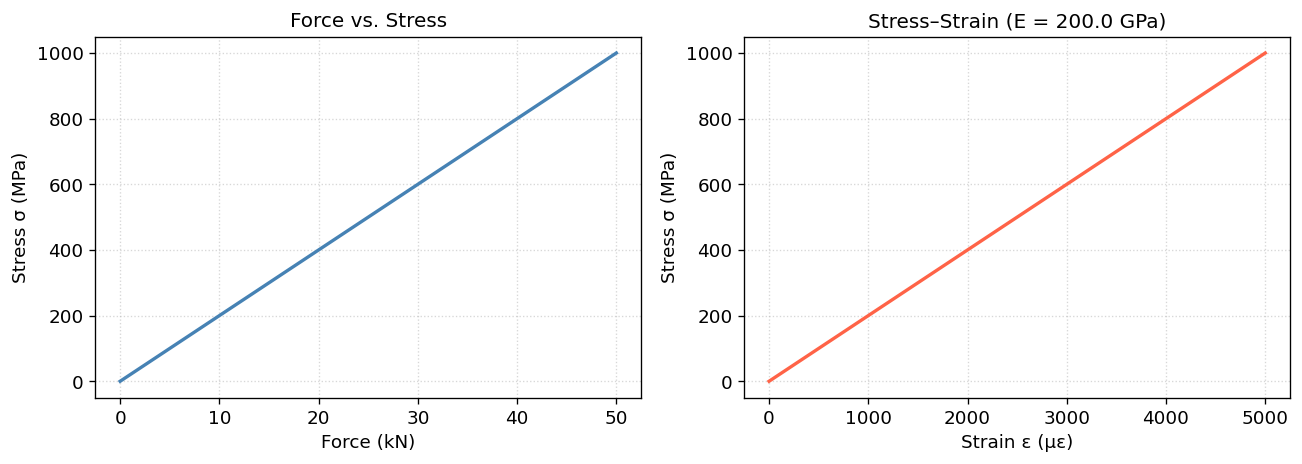

At F = 50.0 kN:  σ = 1000.0 MPa,  ε = 5000.0 με,  δ = 0.5000 mm


In [2]:
# --- USER INPUT: describe the specimen and the load range ---------------------
E_GPa   = 200.0    # Young's modulus (GPa) — 200 for steel, 69 for aluminum, 110 for titanium
L_mm    = 100.0    # specimen gage length (mm)
A_mm2   = 50.0     # cross-sectional area (mm^2)
F_max_N = 50000.0  # maximum applied force (N)
N_POINTS = 200     # number of samples along the load sweep

MPA_PER_GPA          = 1e3  # 1 GPa = 1000 MPa; with N and mm^2, stress comes out in MPa
STRAIN_TO_MICROSTRAIN = 1e6  # dimensionless strain -> microstrain (με)


def axial_response(force_N, area_mm2, length_mm, modulus_GPa):
    """Elastic axial response of a uniform bar in tension (Hooke's Law).

    Applies the material form of Hooke's Law, sigma = E * eps. With force in
    newtons and area in mm^2, stress comes out directly in MPa (1 N/mm^2 = 1 MPa).

    Returns
    -------
    (stress_MPa, strain, extension_mm)
        Each output matches the shape of ``force_N``.
    """
    modulus_MPa  = modulus_GPa * MPA_PER_GPA
    stress_MPa   = force_N / area_mm2       # sigma = F / A
    strain       = stress_MPa / modulus_MPa  # eps = sigma / E  (dimensionless)
    extension_mm = strain * length_mm        # delta = eps * L
    return stress_MPa, strain, extension_mm


F = np.linspace(0, F_max_N, N_POINTS)
sigma, eps, delta = axial_response(F, A_mm2, L_mm, E_GPa)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(F / 1000, sigma, 'steelblue', linewidth=2)
axes[0].set_xlabel('Force (kN)'); axes[0].set_ylabel('Stress σ (MPa)')
axes[0].set_title('Force vs. Stress'); axes[0].grid(True, linestyle=':', alpha=0.5)

axes[1].plot(eps * STRAIN_TO_MICROSTRAIN, sigma, 'tomato', linewidth=2)
axes[1].set_xlabel('Strain ε (με)'); axes[1].set_ylabel('Stress σ (MPa)')
axes[1].set_title(f'Stress–Strain (E = {E_GPa} GPa)')
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_nb1_hookes_law_force_stress.png', bbox_inches='tight', dpi=150)
plt.show()

sigma_max, eps_max, delta_max = axial_response(F_max_N, A_mm2, L_mm, E_GPa)
print(f"At F = {F_max_N/1000:.1f} kN:  "
      f"σ = {sigma_max:.1f} MPa,  "
      f"ε = {eps_max * STRAIN_TO_MICROSTRAIN:.1f} με,  "
      f"δ = {delta_max:.4f} mm")

---
## 2 — Material Comparison: Elastic Strain Across Six Engineering Materials

At the same applied stress, different materials deform by very different amounts. Aluminum, with E ≈ 69 GPa, deforms about three times more than steel at E ≈ 200 GPa. Bone, at E ≈ 20 GPa, deforms ten times more than steel under the same stress — which is why bone injuries are measured in percent-level strains rather than microstrain. This diversity is what makes spring element material selection a genuine engineering decision: a stiffer element produces less strain per unit load, requiring a more sensitive measurement system; a more compliant element produces more strain but may introduce unacceptable structural compliance in the application.

The applied stress in this comparison is 50 MPa — well within the elastic range of all six materials shown, including cortical bone (yield ≈ 170 MPa) and CFRP in the fiber direction (yield exceeds 1000 MPa). The displayed strain values are what a strain gage would read axially on a specimen of each material at that stress level.

For transducer design, the most common spring element materials are aluminum 6061-T6 (E ≈ 69 GPa, good machinability) and 17-4PH stainless steel (E ≈ 197 GPa, excellent corrosion resistance). Titanium (E ≈ 110 GPa) is used where corrosion resistance and biocompatibility are required. The choice balances target full-scale strain (typically 1000–3000 με), operating environment, and required fatigue life.

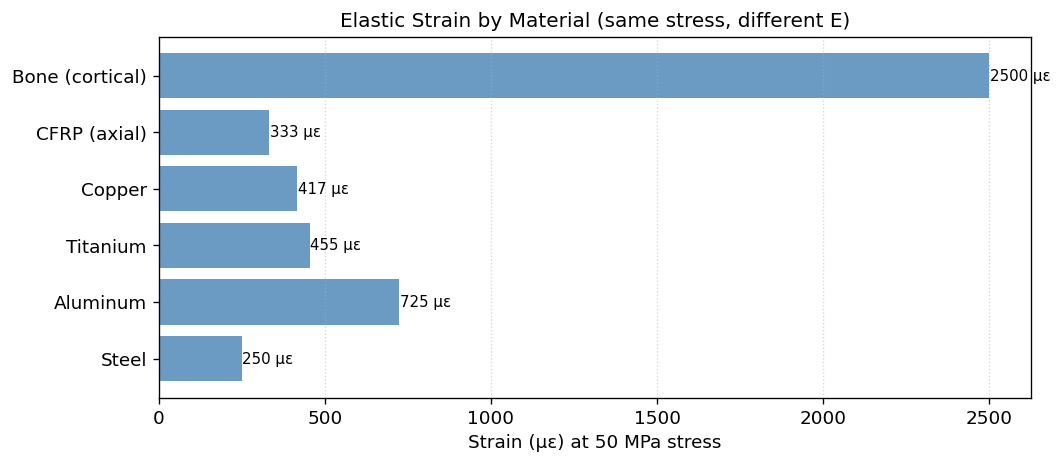

In [3]:
# Representative Young's moduli (GPa) for common structural and biological materials.
MODULUS_GPA = {
    'Steel':           200,
    'Aluminum':         69,
    'Titanium':        110,
    'Copper':          120,
    'CFRP (axial)':    150,
    'Bone (cortical)':  20,
}
COMMON_STRESS_MPA = 50.0  # applied to every material; elastic for all six (bone yields ~170 MPa)
LABEL_OFFSET_UE   = 2.0   # horizontal nudge (με) so value labels clear the bar ends


def elastic_strain_ue(stress_MPa, modulus_GPa):
    """Axial elastic strain from Hooke's Law (eps = sigma / E), returned in microstrain.

    Stress in MPa and modulus in GPa differ by a factor of 1e3, so MPa/GPa is
    millistrain; multiplying by 1e3 converts to microstrain (με).
    """
    return stress_MPa / modulus_GPa * 1e3


names = list(MODULUS_GPA.keys())
strains_ue = [elastic_strain_ue(COMMON_STRESS_MPA, E_gpa) for E_gpa in MODULUS_GPA.values()]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, strains_ue, color='steelblue', alpha=0.8)
ax.set_xlabel(f'Strain (με) at {COMMON_STRESS_MPA:.0f} MPa stress')
ax.set_title('Elastic Strain by Material (same stress, different E)')
for bar, val in zip(bars, strains_ue):
    ax.text(val + LABEL_OFFSET_UE, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} με', va='center', fontsize=9)
ax.grid(True, axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_nb2_material_elastic_strain.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Where to take this next

Hooke's Law is the starting point, not the destination. Three concrete extensions build directly on the code above:

- **Add a yield-strain overlay.** Annotate each material's yield strain on the stress–strain plot so you can see how much *elastic headroom* a spring element has before Hooke's contract breaks — the boundary this chapter calls the end of the linear regime. Steel yields near 1500–2500 με; try shading everything beyond as "off-contract."
- **Size a transducer, don't just plot it.** Wrap `axial_response` in a loop over candidate cross-sections and moduli and solve for the geometry that hits a target full-scale strain — say 1500 με at rated load. That inversion, stress and strain back to geometry, is exactly the spring-element sizing done for real load cells in Part 7.
- **Bring in Poisson's ratio.** Extend the model with the transverse strain ε_t = −ν·ε_axial so the notebook predicts what a *transverse* gage would read alongside the axial one. That two-directional strain state is the groundwork for the biaxial stress analysis developed in Chapters 17–18.